In [1]:
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 92.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.3 MB/s eta 0:00:00


In [2]:
import os
from roboflow import Roboflow
from google.colab import userdata
from ultralytics import YOLO
from ultralytics import RTDETR
import matplotlib.pyplot as plt
import cv2
import numpy as np
import shutil

#for UTF8 error when downloading ultralytics results from colab
import locale
locale.getpreferredencoding = lambda: "UTF-8"

#google drive
from google.colab import drive
drive.mount('/content/drive')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [13]:
def visualize_results_boxes(test_results, result_show_limit=20, txt_save_file=None, gt_count_txt_file="/content/drive/MyDrive/Stave_Project/Developers/staveProjectImgsAll/staves_count.txt"):
  grid_imgs = []
  img_box_counts = []
  img_names = []
  img_gt_counts = {}
  img_name_filters = ["Brandon Wagner_", "jast bentahm_", "Snider_", "HEIC_"]
  with open(gt_count_txt_file, 'r') as f:
      for line in f:
          img_name, gt_count = line.strip().split(':')
          img_name = img_name.split('.')[0]
          img_gt_counts[img_name] = int(gt_count)

  for i, result in enumerate(test_results):
      if i >= result_show_limit:
          break
      # result.plot() returns an image (NumPy array) with predictions overlaid
      img = result.plot()
      grid_imgs.append(img)
      img_box_counts.append(len(result.boxes))
      img_names.append(result.path)
  #print(img_gt_counts)
  #print(img_names)
  cols = 4
  rows = int(np.ceil(len(grid_imgs) / cols))

  fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

  for idx, ax in enumerate(axs.flat):
      if idx < len(grid_imgs):

          ax.imshow(grid_imgs[idx])
          img_name = os.path.basename(img_names[idx]).split('.')[0]

          for filter_str in img_name_filters:
            if filter_str in img_name:
              img_name  = img_name.split('_')[:-1][0]
          #print(img_name)

          ax.set_title(f"{img_box_counts[idx]} staves detected | ground truth: {img_gt_counts[img_name]}")
      ax.axis('off')

  if txt_save_file is not None:
      with open(txt_save_file, 'w') as f:
          for idx, img_name in enumerate(img_names):
              f.write(f"{img_box_counts[idx]} staves detected in image: {img_name}\n")

  plt.tight_layout()
  plt.show()

def visualize_results_box_centers(test_results, result_show_limit=20, txt_save_file=None,
                      gt_count_txt_file="/content/drive/MyDrive/Stave_Project/Developers/staveProjectImgsAll/staves_count.txt"):
    grid_imgs = []
    img_box_counts = []
    img_names = []
    img_gt_counts = {}
    img_name_filters = ["Brandon Wagner_", "jast bentahm_", "Snider_", "HEIC_"]

    with open(gt_count_txt_file, 'r') as f:
        for line in f:
            img_name, gt_count = line.strip().split(':')
            img_name = img_name.split('.')[0]
            img_gt_counts[img_name] = int(gt_count)

    for i, result in enumerate(test_results):
        if i >= result_show_limit:
            break
        img = result.orig_img
        grid_imgs.append(img)
        img_box_counts.append(len(result.boxes))
        img_names.append(result.path)

    cols = 4
    rows = int(np.ceil(len(grid_imgs) / cols))

    fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

    for idx, ax in enumerate(axs.flat):
        if idx < len(grid_imgs):
            img = grid_imgs[idx]
            ax.imshow(img)
            img_name = os.path.basename(img_names[idx]).split('.')[0]

            for filter_str in img_name_filters:
                if filter_str in img_name:
                    img_name = img_name.split('_')[:-1][0]

            result = test_results[idx]
            for box in result.boxes.xyxy.cpu().numpy():
                x_center = (box[0] + box[2]) / 2
                y_center = (box[1] + box[3]) / 2
                ax.plot(x_center, y_center, 'ro', markersize=4)  # red dot

            ax.set_title(f"{img_box_counts[idx]} staves detected | ground truth: {img_gt_counts.get(img_name, '?')}")
            #ax.set_title(f"{img_box_counts[idx]} staves detected")
        ax.axis('off')

    if txt_save_file is not None:
        with open(txt_save_file, 'w') as f:
            for idx, img_name in enumerate(img_names):
                f.write(f"{img_box_counts[idx]} staves detected in image: {img_name}\n")

    plt.tight_layout()
    plt.show()

def get_staves_count_list(test_results):
  staves_count_list = []
  for result in test_results:
    staves_count_list.append(len(result.boxes))
  return staves_count_list
#
def save_results_to_indvidual_txt_files(test_results, output_folder, img_label_subfolder_name_ext="april_7th_add", staves_threshold=900):
  os.makedirs(output_folder, exist_ok=True)
  os.makedirs(os.path.join(output_folder, f"labels_{img_label_subfolder_name_ext}"), exist_ok=True)
  os.makedirs(os.path.join(output_folder, f"images_{img_label_subfolder_name_ext}"), exist_ok=True)

  labels_folder = os.path.join(output_folder, f"labels_{img_label_subfolder_name_ext}")
  images_folder = os.path.join(output_folder, f"images_{img_label_subfolder_name_ext}")

  for i, result in enumerate(test_results):
    img_path = result.path
    img_name = os.path.basename(img_path)
    img_name_without_ext = os.path.splitext(img_name)[0]
    txt_file_path = os.path.join(output_folder, labels_folder, f"{img_name_without_ext}.txt")

    conf_list = result.boxes.conf.cpu().numpy()
    box_list = result.boxes.xywhn
    cls_list = result.boxes.cls.cpu().numpy()

    box_count = len(conf_list)
    if box_count>=staves_threshold:
      shutil.copy(img_path, os.path.join(output_folder, images_folder, img_name))
      with open(txt_file_path, 'a') as result_file:
        for conf, box, cls in zip(conf_list, box_list, cls_list):
          if conf>0.1:
            result_file.write(f"{int(cls)} {box[0]} {box[1]} {box[2]} {box[3]}\n")

In [14]:
#weights_path = "/content/drive/MyDrive/Stave_Project/Developers/modelWeights/plankModel/detect/train2/weights/best.pt"
weights_path = "/content/drive/MyDrive/Stave_Project/Developers/modelWeights/runs/detect/staves2img200epYolo11Ultralytics8340V2/weights/best.pt"
input_folder = "/content/drive/MyDrive/Stave_Project/Developers/imagesAdditionTrainApril7"
output_folder = "/content/drive/MyDrive/Stave_Project/Developers/staveProjectImgsAllCroppedResults"

In [15]:
model = YOLO(weights_path)
test_results = []
for result in model.predict(source=input_folder, half=True, stream=True, max_det=3000, device=0):
  test_results.append(result)


image 1/20 /content/drive/MyDrive/Stave_Project/Developers/imagesAdditionTrainApril7/17295226829861331060200319772865 - Brandon Wagner.jpeg: 320x512 487 staves_regions, 14.6ms
image 2/20 /content/drive/MyDrive/Stave_Project/Developers/imagesAdditionTrainApril7/17296035787962115044195924172172 - Brandon Wagner.jpeg: 288x512 533 staves_regions, 14.8ms
image 3/20 /content/drive/MyDrive/Stave_Project/Developers/imagesAdditionTrainApril7/17343748770805448639774007302529 - Brandon Wagner.jpeg: 320x512 485 staves_regions, 14.4ms
image 4/20 /content/drive/MyDrive/Stave_Project/Developers/imagesAdditionTrainApril7/IMG_2980 - Patrick PortellHEIC.jpeg: 320x512 489 staves_regions, 13.9ms
image 5/20 /content/drive/MyDrive/Stave_Project/Developers/imagesAdditionTrainApril7/IMG_2987 - Patrick PortellHEIC.jpeg: 320x512 545 staves_regions, 13.7ms
image 6/20 /content/drive/MyDrive/Stave_Project/Developers/imagesAdditionTrainApril7/IMG_3017 - Patrick PortellHEIC.jpeg: 320x512 487 staves_regions, 14.9ms


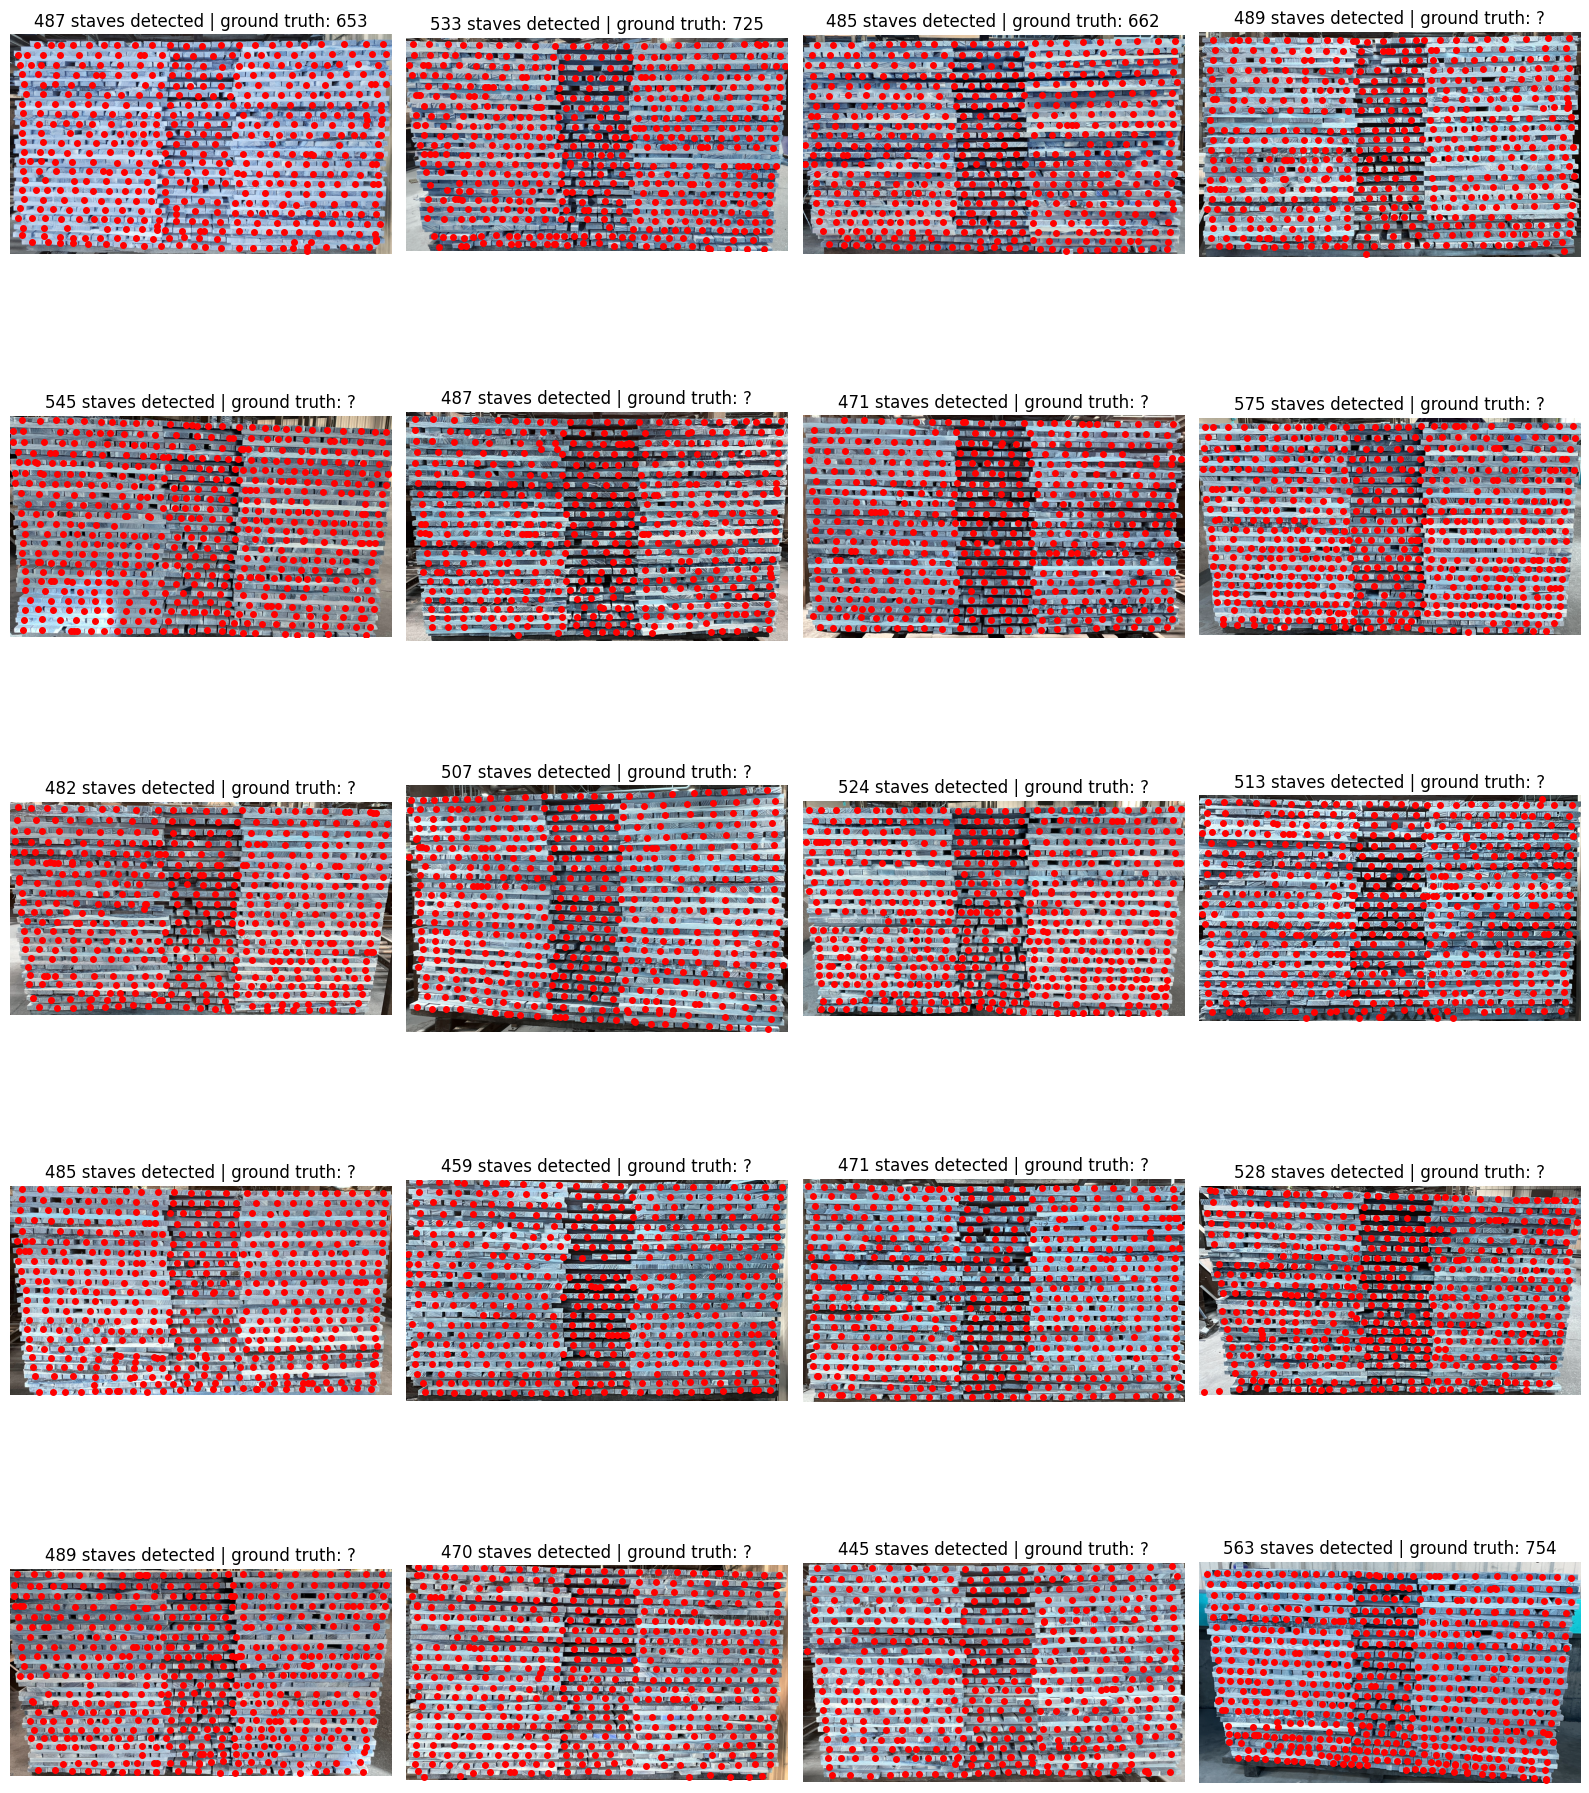

In [16]:
visualize_results_box_centers(test_results, result_show_limit=200)
save_results_to_indvidual_txt_files(test_results, output_folder)